In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import xgboost as xgb
from scipy.signal import find_peaks
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
import joblib
import shutil
import os
import re

# Load in Position Data

In [2]:
TRAIN_FOLDER = "Train"
EVAL_FOLDER = "Evaluate"
MODELS_FOLDER = "models"
PREDICTIONS_FOLDER = "predictions"

In [3]:
def load_games_from_folder(folder_path):
    """
    Load (positions, events) pairs from a folder.
    Returns: list of (game_df, events_df, game_id)
    """
    folder = Path(folder_path)
    games = []

    game_files = sorted(folder.glob("game*.csv"))

    for game_file in game_files:
        match = re.search(r"game(\d+)", game_file.stem)
        if not match:
            continue

        game_id = match.group(1)
        events_file = folder / f"RugbyEvents{game_id}.csv"

        if not events_file.exists():
            print(f"⚠️ Missing events for game {game_id}, skipping")
            continue

        game_df = pd.read_csv(game_file)
        events_df = pd.read_csv(events_file)

        games.append((game_df, events_df, game_id))

    return games

# Merge Positions and Events

In [4]:
def load_game(df):
    df = df.drop(columns=['team'], errors='ignore')
    df['x_med'] = df.groupby('frame')['x'].transform('median')
    df['team'] = (df['x'] >= df['x_med']).astype(int) + 1
    return df

def process_game(game_df, events_df):
    game_df = load_game(game_df)

    upsampled_rows = []
    frame_indices = sorted(game_df['frame'].astype(int).unique())

    for i in range(len(frame_indices)):
        cur = int(frame_indices[i])
        nxt = int(frame_indices[i+1]) if i+1 < len(frame_indices) else cur + 1
        current_frame_data = game_df[game_df['frame'] == cur]

        for f in range(cur, nxt):
            temp = current_frame_data.copy()
            temp['frame'] = f
            upsampled_rows.append(temp)

    game_upsampled = pd.concat(upsampled_rows, ignore_index=True)

    events_df = events_df.rename(columns={
        'Event': 'event',
        'Frame_Start': 'frame_start',
        'Frame_End': 'frame_end',
        'Team': 'event_team'
    })

    expanded_events = []
    for _, row in events_df.iterrows():
        expanded_events.extend([
            {'frame': f, 'event': row['event'], 'event_team': row['event_team']}
            for f in range(row['frame_start'], row['frame_end'] + 1)
        ])

    expanded_events = pd.DataFrame(expanded_events)
    game_data = game_upsampled.merge(expanded_events, on='frame', how='left')
    return game_data.loc[:, ~game_data.columns.duplicated()]

def load_or_process_game(game_df, events_df, game_id, cache_folder="Game_data"):
    """Load cached game data if exists, otherwise process and save"""
    cache_path = Path(cache_folder) / f"game_data{game_id}.csv"
    
    # Check if already processed
    if cache_path.exists():
        print(f"✓ Loading cached game_data{game_id}.csv")
        return pd.read_csv(cache_path)
    
    # Otherwise process and save
    print(f"Processing game {game_id}...")
    df = process_game(game_df, events_df)
    
    # Save for future use
    Path(cache_folder).mkdir(exist_ok=True)
    df.to_csv(cache_path, index=False)
    print(f"✓ Saved game_data{game_id}.csv")
    
    return df

# Helper Functions

In [5]:
def normalize_positions(df):
    df = df.copy()
    df['x'] = (df['x'] - df['x'].min()) / (df['x'].max() - df['x'].min())
    df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())
    df['event'] = df['event'].replace('Kick', np.nan)
    return df

In [6]:
def create_class_weights(training_data):
    """Assign sample weights to balance classes"""
    
    # Count number of examples per class
    class_counts = training_data['event'].value_counts()
    
    # Inverse frequency weighting
    total = len(training_data)
    class_weights = {cls: total/count for cls, count in class_counts.items()}
    
    # Optional: normalize weights to avoid extremely large numbers
    max_weight = max(class_weights.values())
    class_weights = {cls: weight / max_weight for cls, weight in class_weights.items()}
    
    training_data['sample_weight'] = training_data['event'].apply(lambda x: class_weights[x])
    
    return training_data


In [7]:
def detect_event_peaks_adaptive_conf(frame_feats, clf, feature_cols, le, thresholds, min_distance_default=200):

    X = frame_feats[feature_cols].fillna(0)
    probs = clf.predict_proba(X)
    inv = {i: lab for i, lab in enumerate(le.classes_)}
    peak_rows = []

    for cls_idx, cls_label in inv.items():
        if cls_label == "OpenPlay":
            continue

        # ⭐ ADAPTIVE CONFIDENCE THRESHOLD
        min_conf = thresholds.get(cls_label, 0.5)

        class_prob = probs[:, cls_idx]

        # Smooth signal
        smoothed = pd.Series(class_prob).rolling(7, center=True, min_periods=1).mean()

        # Peak detection
        peaks, _ = find_peaks(
            smoothed, 
            height=min_conf, 
            distance=min_distance_default
        )

        for p in peaks:
            peak_rows.append({
                "frame": frame_feats.iloc[p]["frame"],
                "event_smooth": cls_label,
                "confidence": class_prob[p]
            })

    return pd.DataFrame(peak_rows)

In [8]:
def post_filter_predictions(predictions, min_frame_gap=300):
    """Remove duplicate predictions that are too close together"""
    if len(predictions) == 0:
        return predictions
    
    filtered = predictions.sort_values(['event_smooth', 'frame'])
    to_keep = []
    
    for event_type in filtered['event_smooth'].unique():
        event_preds = filtered[filtered['event_smooth'] == event_type]
        if len(event_preds) == 0:
            continue
        
        kept_indices = [event_preds.index[0]]
        last_kept_frame = event_preds.iloc[0]['frame']
        
        for idx, row in event_preds.iloc[1:].iterrows():
            if row['frame'] - last_kept_frame > min_frame_gap:
                kept_indices.append(idx)
                last_kept_frame = row['frame']
        
        to_keep.extend(kept_indices)
    
    return filtered.loc[to_keep].sort_values('frame').reset_index(drop=True)

In [9]:
def build_event_intervals(event_df):
    """Convert frame-level events to intervals"""
    event_df = event_df.sort_values('frame').reset_index(drop=True)
    intervals = []
    prev_event = None
    start_frame = None

    for i, row in event_df.iterrows():
        if row['event'] != prev_event:
            if prev_event is not None:
                intervals.append({
                    'event': prev_event,
                    'start_frame': start_frame,
                    'end_frame': event_df.iloc[i-1]['frame']
                })
            prev_event = row['event']
            start_frame = row['frame']

    if prev_event is not None:
        intervals.append({
            'event': prev_event,
            'start_frame': start_frame,
            'end_frame': event_df.iloc[-1]['frame']
        })
    
    return pd.DataFrame(intervals)

In [10]:
def evaluate_predictions(predicted_events, ground_truth_intervals, method_name="Model"):
    if len(predicted_events) == 0:
        print(f"{method_name}: No events predicted!")
        return None

    # Check if predictions fall within ground truth intervals
    def check_correct(row):
        pred_frame = row['frame']
        pred_event = row['event_smooth']
        
        matching = ground_truth_intervals[
            (ground_truth_intervals['event'] == pred_event) &
            (ground_truth_intervals['start_frame'] <= pred_frame) &
            (ground_truth_intervals['end_frame'] >= pred_frame)
        ]
        return len(matching) > 0

    predicted_events['correct'] = predicted_events.apply(check_correct, axis=1)

    precision = predicted_events['correct'].mean() if len(predicted_events) > 0 else 0

    # Recall: did we detect each ground truth event?
    recall_results = []
    for event in ground_truth_intervals['event'].unique():
        actual_intervals = ground_truth_intervals[ground_truth_intervals['event'] == event]
        detected = 0
        for _, interval in actual_intervals.iterrows():
            any_pred = predicted_events[
                (predicted_events['event_smooth'] == event) &
                (predicted_events['frame'] >= interval['start_frame']) &
                (predicted_events['frame'] <= interval['end_frame'])
            ]
            if len(any_pred) > 0:
                detected += 1
        recall = detected / len(actual_intervals) if len(actual_intervals) > 0 else 0
        recall_results.append({'event': event, 'recall': recall, 'detected': detected, 'total': len(actual_intervals)})

    recall_df = pd.DataFrame(recall_results)
    avg_recall = recall_df['recall'].mean()
    f1 = 2 * (precision * avg_recall) / (precision + avg_recall) if (precision + avg_recall) > 0 else 0

    print(f"\n{method_name}")
    print(f"  Precision: {precision:.2%}")
    print(f"  Recall: {avg_recall:.2%}")
    print(f"  F1 Score: {f1:.2%}")
    print(f"  Predictions: {len(predicted_events)}")

    return {
        'method': method_name,
        'precision': precision,
        'recall': avg_recall,
        'f1': f1,
        'predictions': predicted_events,
        'recall_by_event': recall_df
    }


# Feature Extraction

In [11]:
def extract_features(df):
    df = df.copy()
    if 'dx' not in df.columns:
        df['dx'] = 0
    if 'dy' not in df.columns:
        df['dy'] = 0

    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2)
    df['theta'] = np.arctan2(df['dy'], df['dx'])

    if 'team' not in df.columns:
        return pd.DataFrame()

    df = df[df['team'].notna() & df['team'].isin([1, 2])]
    if len(df) == 0:
        return pd.DataFrame()

    df = df.sort_values(['frame', 'team'])

    df['y_rank_low'] = df.groupby(['frame', 'team'])['y'].rank(method='first', ascending=True)
    df['y_rank_high'] = df.groupby(['frame', 'team'])['y'].rank(method='first', ascending=False)
    df['x_rank_low'] = df.groupby(['frame', 'team'])['x'].rank(method='first', ascending=True)
    df['x_rank_high'] = df.groupby(['frame', 'team'])['x'].rank(method='first', ascending=False)

    df['y_low3'] = df['y'].where(df['y_rank_low'] <= 3)
    df['y_high3'] = df['y'].where(df['y_rank_high'] <= 3)
    df['x_low3'] = df['x'].where(df['x_rank_low'] <= 3)
    df['x_high3'] = df['x'].where(df['x_rank_high'] <= 3)

    agg = df.groupby(['frame', 'team']).agg(
        x_mean=('x','mean'),
        y_mean=('y','mean'),
        x_std=('x','std'),
        y_std=('y','std'),
        x_max=('x','max'),
        x_min=('x','min'),
        y_max=('y','max'),
        y_min=('y','min'),

        y_low3_min=('y_low3','min'),
        y_low3_max=('y_low3','max'),
        y_high3_min=('y_high3','min'),
        y_high3_max=('y_high3','max'),

        x_low3_min=('x_low3','min'),
        x_low3_max=('x_low3','max'),
        x_high3_min=('x_high3','min'),
        x_high3_max=('x_high3','max'),

        dx_mean=('dx','mean'),
        dx_std=('dx','std'),
        dy_mean=('dy','mean'),
        dy_std=('dy','std'),
        speed_mean=('speed','mean'),
        speed_std=('speed','std'),
        speed_max=('speed','max'),
        speed_min=('speed','min'),
        theta_mean=('theta','mean'),
        theta_std=('theta','std'),
        count=('x','count')
    ).reset_index()


    agg['width_x'] = agg['x_max'] - agg['x_min']
    agg['depth_y'] = agg['y_max'] - agg['y_min']
    agg['compression'] = agg['width_x'] / (agg['depth_y'] + 1)
    agg['front_x'] = agg['x_max']
    agg['compactness'] = agg['count'] / (agg['width_x'] * agg['depth_y'] + 1)

    white = agg[agg['team'] == 1].set_index('frame').drop(columns='team').add_suffix('_white')
    black = agg[agg['team'] == 2].set_index('frame').drop(columns='team').add_suffix('_black')
    features = white.join(black, how='outer').reset_index()

    features['front_player_sep'] = (features['front_x_black'] - features['front_x_white']).abs()
    features['speed_differential'] = (features['speed_mean_black'] - features['speed_mean_white']).abs()
    features['dx_diff'] = (features['dx_mean_black'] - features['dx_mean_white']).abs()
    features['dy_diff'] = (features['dy_mean_black'] - features['dy_mean_white']).abs()
    features['compression_diff'] = (features['compression_black'] - features['compression_white']).abs()
    features['team_sep'] = np.sqrt(
        (features['x_mean_black'] - features['x_mean_white'])**2 +
        (features['y_mean_black'] - features['y_mean_white'])**2
    )
    features['avg_team_speed'] = (
        features['speed_mean_black'].fillna(0) +
        features['speed_mean_white'].fillna(0)
    ) / 2

    features['theta_change_white'] = features['theta_mean_white'].diff()
    features['theta_change_black'] = features['theta_mean_black'].diff()
    features['acceleration'] = features['avg_team_speed'].diff()
    features['jerk'] = features['acceleration'].diff()

    features['near_left_touchline'] = ((features['x_mean_white'] < 0.1) | (features['x_mean_black'] < 0.1)).astype(int)
    features['near_right_touchline'] = ((features['x_mean_white'] > 0.9) | (features['x_mean_black'] > 0.9)).astype(int)
    features['near_tryline_top'] = ((features['y_mean_white'] < 0.1) | (features['y_mean_black'] < 0.1)).astype(int)
    features['near_tryline_bottom'] = ((features['y_mean_white'] > 0.9) | (features['y_mean_black'] > 0.9)).astype(int)

    features['in_tryzone'] = (
        (features['y_mean_white'] < 0.07) | (features['y_mean_black'] < 0.07) |
        (features['y_mean_white'] > 0.93) | (features['y_mean_black'] > 0.93)
    ).astype(int)

    features['scrum_score'] = (
        (1 / (features['width_x_white'] + 0.01)) +
        (1 / (features['width_x_black'] + 0.01))
    ) * (1 / (features['team_sep'] + 0.01)) * (1 / (features['avg_team_speed'] + 0.01))

    features['lineout_score'] = (
        (1 / (features['width_x_white'] + 0.01)) +
        (1 / (features['width_x_black'] + 0.01))
    ) * (features['depth_y_white'].fillna(0) + features['depth_y_black'].fillna(0))

    features['try_score'] = features['in_tryzone'] * (1 / (features['avg_team_speed'] + 0.01))

    features['kick_score'] = (
        (((features['speed_mean_white'] < 0.2) | (features['speed_mean_black'] < 0.2)).astype(int)) *
        (((features['width_x_white'] > 0.3) | (features['width_x_black'] > 0.3)).astype(int))
    )

    WINDOWS = [25, 100, 250, 500]
    BASE_COLS = [
        'avg_team_speed', 'team_sep',
        'compactness_white', 'compactness_black',
        'scrum_score', 'lineout_score',
        'try_score', 'acceleration'
    ]

    new_features = {}

    for col in BASE_COLS:
        s = features[col].astype(float)
        for w in WINDOWS:
            new_features[f'{col}_roll_center_mean_{w}'] = s.rolling(2*w+1, center=True, min_periods=1).mean().values
            new_features[f'{col}_roll_center_std_{w}'] = s.rolling(2*w+1, center=True, min_periods=1).std().values
            new_features[f'{col}_roll_center_max_{w}'] = s.rolling(2*w+1, center=True, min_periods=1).max().values
            new_features[f'{col}_roll_center_min_{w}'] = s.rolling(2*w+1, center=True, min_periods=1).min().values
            new_features[f'{col}_lag_pos_{w}'] = s.shift(w).bfill().values
            new_features[f'{col}_lag_neg_{w}'] = s.shift(-w).ffill().values

    VEL_DIFFS = [25, 100, 250, 500]
    for col in ['avg_team_speed', 'team_sep', 'compactness_white', 'compactness_black']:
        s = features[col].astype(float)
        for d in VEL_DIFFS:
            new_features[f'{col}_vel_center_{d}'] = (s.shift(-d).ffill() - s.shift(d).bfill()).values
            new_features[f'{col}_vel_forward_{d}'] = (s.shift(-d).ffill() - s).values
            new_features[f'{col}_vel_backward_{d}'] = (s - s.shift(d).bfill()).values

    new_features['sudden_stop'] = (
        (features['avg_team_speed'].shift(1).fillna(0) > 0.5) &
        (features['avg_team_speed'] < 0.15)
    ).astype(int).values

    new_features['accel_1s'] = features['avg_team_speed'].diff(25).values
    new_features['explosive_acceleration'] = (features['avg_team_speed'].diff(25) > 0.25).astype(int).values
    new_features['hard_deceleration'] = (features['avg_team_speed'].diff(25) < -0.25).astype(int).values

    new_features['formation_disruption'] = (
        features['x_std_white'].diff().abs() +
        features['x_std_black'].diff().abs()
    ).values

    new_features['momentum_change'] = (
        features['avg_team_speed'].diff().abs() +
        features['team_sep'].diff().abs()
    ).values

    features = pd.concat([features, pd.DataFrame(new_features, index=features.index)], axis=1)
    return features


In [12]:
def build_temporal_features(feats_df, feature_cols, window=100):
    """
    Add temporal window statistics for selected features.
    Use sparingly to avoid feature explosion.
    """
    
    df = feats_df.copy()
    arr = df[feature_cols].values
    N, F = arr.shape

    feats = {}

    def roll_stat(func, name):
        rolled = np.zeros_like(arr)
        for i in range(N):
            left = max(0, i - window)
            right = min(N, i + window + 1)
            rolled[i] = func(arr[left:right], axis=0)
        for j, col in enumerate(feature_cols):
            feats[f"{col}_{name}"] = rolled[:, j]

    roll_stat(np.mean, "mean")
    roll_stat(np.std,  "std")
    roll_stat(np.max,  "max")

    delta_forward = np.zeros_like(arr)
    delta_forward[:-1] = arr[1:] - arr[:-1]

    for j, col in enumerate(feature_cols):
        feats[f"{col}_dfwd"] = delta_forward[:, j]

    df_out = pd.concat([df.reset_index(drop=True), pd.DataFrame(feats)], axis=1)

    return df_out

# Train and Evaluate

In [13]:
def reverse_features(feats):
    rev = feats.copy().sort_values('frame', ascending=False)
    rev['frame'] = np.sort(rev['frame'].values)
    return rev

def train_and_evaluate(train_df, train_feats, test_df, test_feats, feature_cols, name,
                       thresholds,
                       min_frame_gap=300):

    print(f"\n{'='*80}")
    print(name)
    print(f"{'='*80}")
    
    gt_train = train_df[train_df['event'].notna()][['frame', 'event']].drop_duplicates('frame')
    gt_test = test_df[test_df['event'].notna()][['frame', 'event']].drop_duplicates('frame')

    training_data = train_feats.merge(gt_train, on='frame', how='inner')

    available_nonevent = train_feats[~train_feats['frame'].isin(gt_train['frame'])]
    n_nonevents = min(5000, len(available_nonevent))
    nonevent = available_nonevent.sample(n=n_nonevents, random_state=42)
    nonevent["event"] = "NonEvent"

    training_full = pd.concat([training_data, nonevent], ignore_index=True)
    training_full = create_class_weights(training_full)

    le = LabelEncoder()
    y_train = le.fit_transform(training_full['event'])
    X_train = training_full[feature_cols].fillna(0)
    sample_weights = training_full['sample_weight'].values

    clf = xgb.XGBClassifier(
        n_estimators=1500,
        max_depth=8,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.7,
        colsample_bylevel=0.7,
        min_child_weight=10,
        gamma=0.3,
        reg_alpha=0.1,
        reg_lambda=3.0,
        max_delta_step=1,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    )

    clf.fit(X_train, y_train, sample_weight=sample_weights, verbose=1)

    print("\n✓ XGBoost model trained")

    preds_forward = detect_event_peaks_adaptive_conf(
        frame_feats=test_feats,
        clf=clf,
        feature_cols=feature_cols,
        le=le,
        thresholds=thresholds,
        min_distance_default=200
    )

    test_feats_rev = reverse_features(test_feats)

    preds_backward = detect_event_peaks_adaptive_conf(
        frame_feats=test_feats_rev,
        clf=clf,
        feature_cols=feature_cols,
        le=le,
        thresholds=thresholds,
        min_distance_default=200
    )

    preds_backward = preds_backward.sort_values('frame')

    merged = preds_forward.copy()

    if 'event_smooth' in merged.columns:
        merged['event_smooth'] = np.where(
            preds_forward['event_smooth'].isna() | (preds_forward['event_smooth'] == -1),
            preds_backward['event_smooth'],
            preds_forward['event_smooth']
        )

    if 'confidence' in merged.columns:
        merged['confidence'] = np.maximum(preds_forward['confidence'], preds_backward['confidence'])

    predictions = merged

    predictions['event_smooth'] = predictions['event_smooth'].apply(
        lambda x: le.classes_[x] if isinstance(x, int) else x
    )

    predictions = post_filter_predictions(predictions, min_frame_gap=min_frame_gap)

    print(f"✓ Generated {len(predictions)} predictions after post-filtering")

    gt_test_intervals = build_event_intervals(gt_test)
    results = evaluate_predictions(predictions, gt_test_intervals, method_name=name)

    results['ground_truth_raw'] = gt_test
    results['clf'] = clf
    results['label_encoder'] = le

    return results


# Visualisation

In [14]:
def plot_comparison_timeline(predictions, ground_truth_raw):
    """Timeline visualization of predictions vs ground truth"""
    fig, ax = plt.subplots(1, 1, figsize=(22, 8))
    
    # Extract just the peak frames from ground truth
    if 'is_peak' in ground_truth_raw.columns:
        gt_peaks = ground_truth_raw[ground_truth_raw['is_peak'] == True]
    else:
        gt_peaks = ground_truth_raw.sort_values('frame')
        gt_peaks = gt_peaks[
            (gt_peaks['event'] != gt_peaks['event'].shift(1)) | 
            (gt_peaks['frame'] != gt_peaks['frame'].shift(1))
        ]
    
    event_types = sorted(set(gt_peaks['event'].unique()) |
                         set(predictions['event_smooth'].unique()))
    event_to_y = {event: idx for idx, event in enumerate(event_types)}
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(event_types)))
    color_map = dict(zip(event_types, colors))
    
    # Ground truth
    ax.scatter(
        gt_peaks['frame'],
        gt_peaks['event'].map(event_to_y),
        s=200, marker='|', linewidths=4,
        c=gt_peaks['event'].map(color_map), 
        zorder=2, label='Ground Truth', alpha=0.9
    )
    
    # Predictions (offset)
    ax.scatter(
        predictions["frame"],
        predictions["event_smooth"].map(event_to_y) + 0.15,
        s=100, marker='o',
        c=predictions["event_smooth"].map(color_map),
        edgecolors="black", linewidths=1.5, alpha=0.8,
        label='Predictions', zorder=3
    )
    
    ax.set_title("Event Detection Timeline", fontsize=14, fontweight='bold')
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Event Type', fontsize=12)
    ax.set_yticks(range(len(event_types)))
    ax.set_yticklabels(event_types)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_performance_comparison(results1, results2):
    """Compare performance metrics between two models"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    methods = [results1['method'], results2['method']]
    metrics = ['precision', 'recall', 'f1']
    metric_names = ['Precision', 'Recall', 'F1 Score']
    
    for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
        values = [results1[metric], results2[metric]]
        bars = axes[idx].bar(methods, values, color=['#3498db', '#e74c3c'], alpha=0.7)
        axes[idx].set_ylabel(name, fontsize=12, fontweight='bold')
        axes[idx].set_ylim(0, 1)
        axes[idx].set_title(name, fontsize=13, fontweight='bold')
        
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(
                bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=11, fontweight='bold'
            )
    
    plt.tight_layout()
    plt.show()


def plot_feature_importance(clf, feature_cols, top_n=20):
    """Plot top feature importances"""
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': clf.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(importance_df)), importance_df['importance'])
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# MAIN

✓ Loading cached game_data1.csv


/var/folders/jv/8l57r4g176g_zkjckpl152mh0000gn/T/ipykernel_50790/2250403063.py:50: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(cache_path)


✓ Loaded 1 training games
✓ Loading cached game_data2.csv


/var/folders/jv/8l57r4g176g_zkjckpl152mh0000gn/T/ipykernel_50790/2250403063.py:50: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(cache_path)


✓ Loaded 1 evaluation games

Extracting features...

XGBoost Event Detector

✓ XGBoost model trained
✓ Generated 101 predictions after post-filtering

XGBoost Event Detector
  Precision: 4.95%
  Recall: 7.94%
  F1 Score: 6.10%
  Predictions: 101
🗑️ Deleted old model: event_model_latest.joblib

✓ Model saved: models/event_model_latest.joblib

GENERATING VISUALIZATIONS



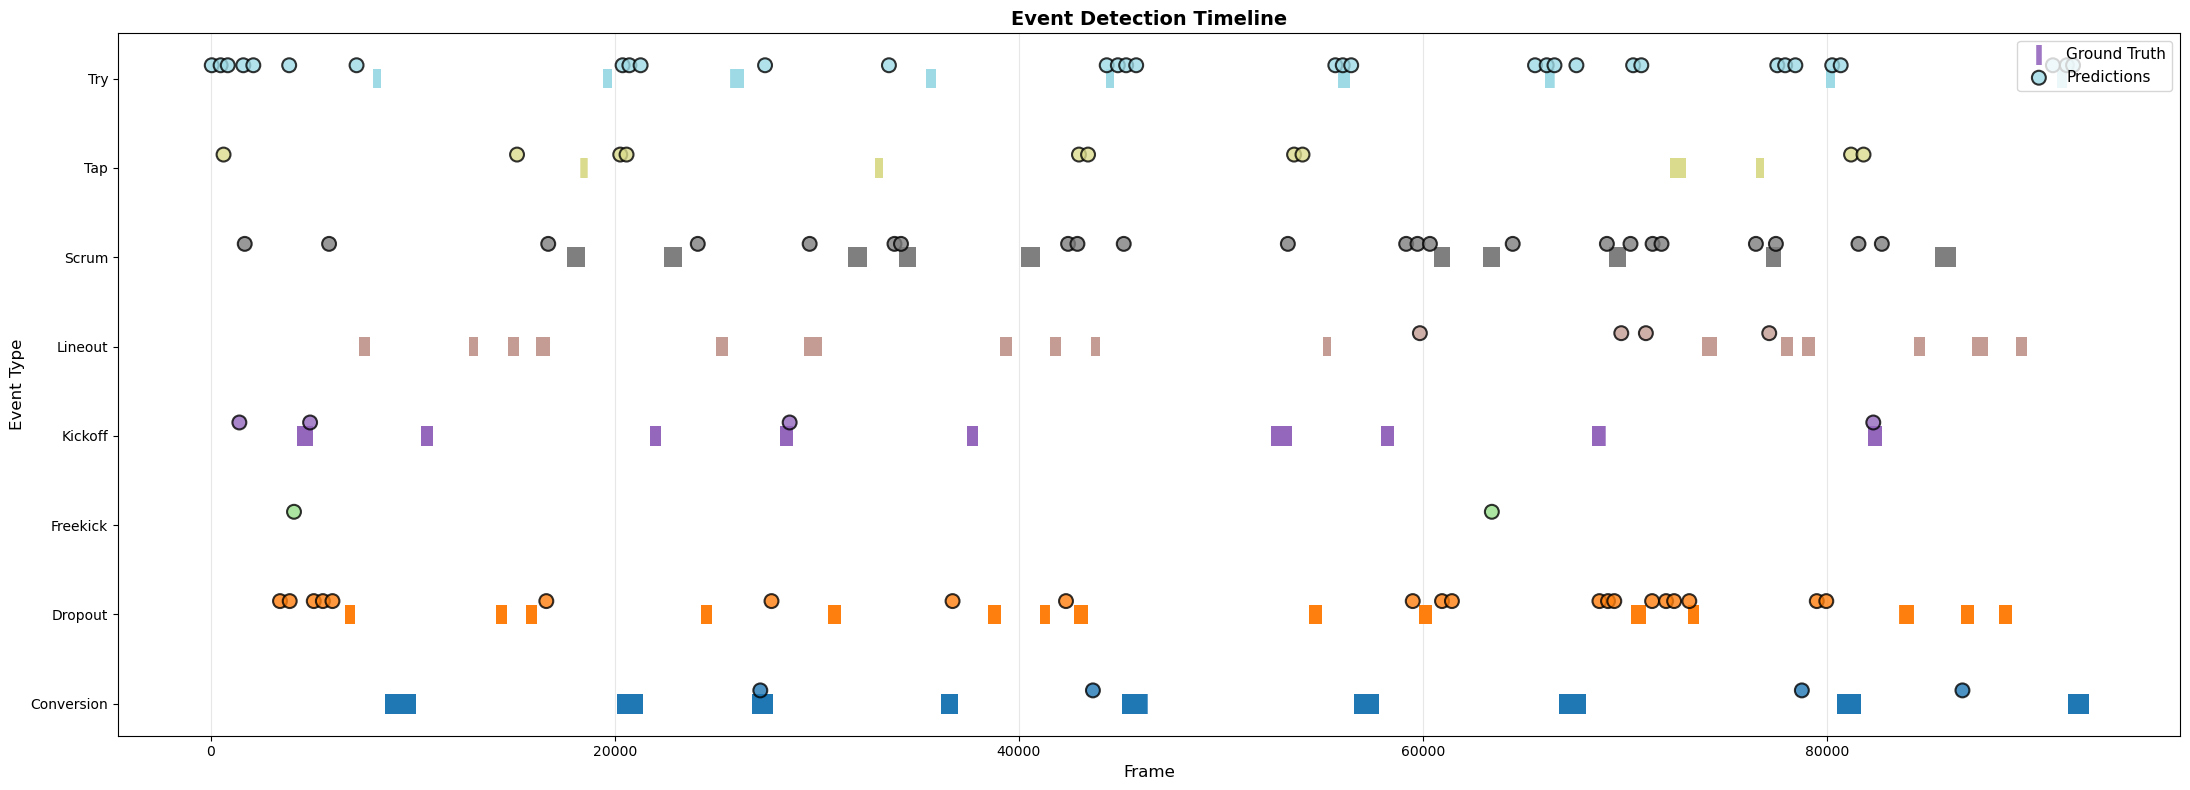

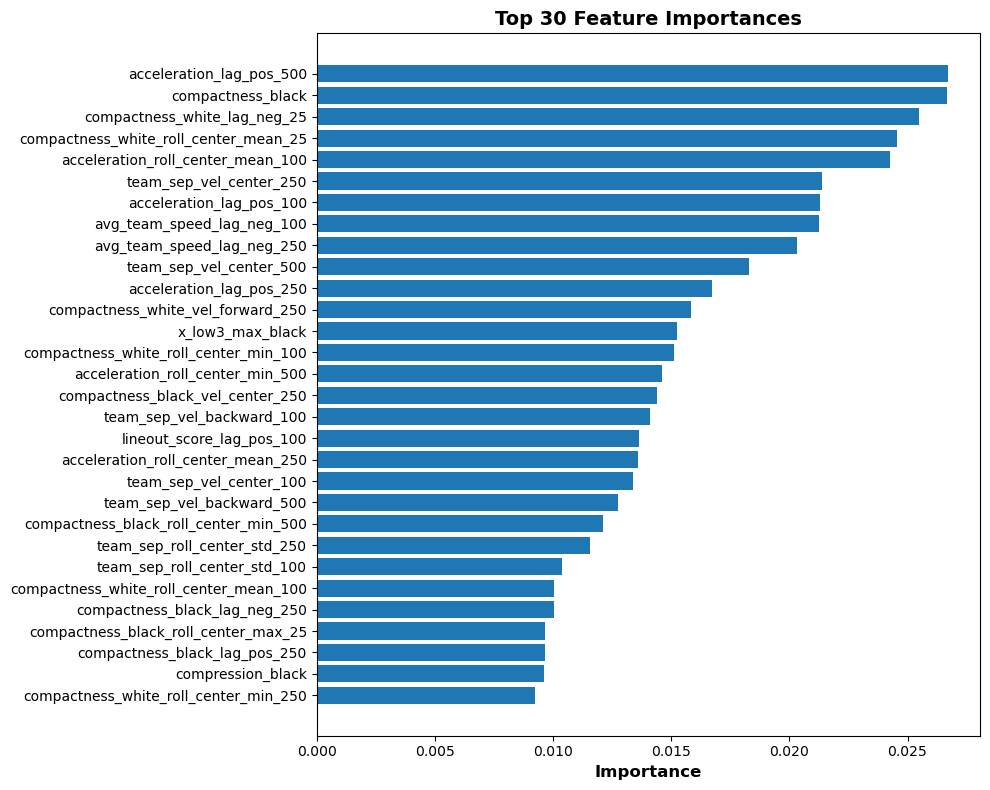

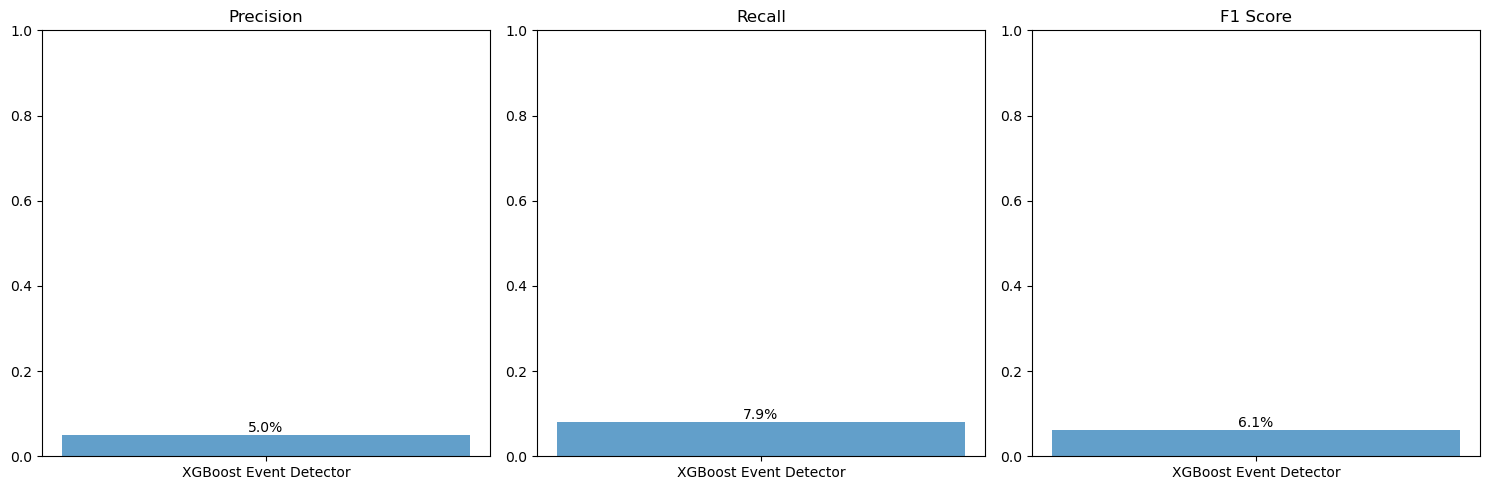


RECALL BY EVENT TYPE
     event   recall  detected  total
   Kickoff 0.222222         2      9
   Dropout 0.000000         0     15
   Lineout 0.000000         0     15
       Try 0.111111         1      9
Conversion 0.111111         1      9
     Scrum 0.111111         1      9
       Tap 0.000000         0      4
🗑️ Deleted old model bundle: model_bundle_latest.joblib

✓ Complete model bundle saved to: models/model_bundle_latest.joblib

✓ Cleared predictions folder: predictions

✓ Cleared predictions folder: predictions


In [15]:
def run_pipeline():

    # ----------------------------
    # LOAD TRAINING DATA
    # ----------------------------
    train_games = load_games_from_folder(TRAIN_FOLDER)
    if len(train_games) == 0:
        raise RuntimeError("❌ No training games found")

    train_dfs = []
    for game_df, events_df, gid in train_games:
        df = load_or_process_game(game_df, events_df, gid)
        df = normalize_positions(df)

        if 'dx' not in df.columns:
            df = df.sort_values('frame')
            df['dx'] = df['x'].diff().fillna(0)
            df['dy'] = df['y'].diff().fillna(0)

        train_dfs.append(df)

    train_df = pd.concat(train_dfs, ignore_index=True)
    print(f"✓ Loaded {len(train_games)} training games")

    # ----------------------------
    # LOAD EVALUATION DATA (OPTIONAL)
    # ----------------------------
    eval_games = load_games_from_folder(EVAL_FOLDER)
    DO_EVAL = len(eval_games) > 0

    if DO_EVAL:
        eval_dfs = []
        for game_df, events_df, gid in eval_games:
            df = load_or_process_game(game_df, events_df, gid)
            df = normalize_positions(df)

            if 'dx' not in df.columns:
                df = df.sort_values('frame')
                df['dx'] = df['x'].diff().fillna(0)
                df['dy'] = df['y'].diff().fillna(0)

            eval_dfs.append(df)

        test_df = pd.concat(eval_dfs, ignore_index=True)
        print(f"✓ Loaded {len(eval_games)} evaluation games")
    else:
        test_df = None
        print("⚠️ No evaluation games found — TRAIN ONLY MODE")

    # ----------------------------
    # FEATURE PIPELINE
    # ----------------------------
    print("\nExtracting features...")
    train_feats = extract_features(train_df)
    if DO_EVAL:
        test_feats = extract_features(test_df)

    exclude_cols = ['frame', 'event', 'team', 'event_team']
    base_cols = [c for c in train_feats.columns if c not in exclude_cols]

    train_feats = build_temporal_features(train_feats, base_cols, window=50)
    if DO_EVAL:
        test_feats = build_temporal_features(test_feats, base_cols, window=50)

    var = train_feats[base_cols].var()
    feature_cols = var[var > 1e-6].index.tolist()

    # ----------------------------
    # TRAIN MODEL
    # ----------------------------
    thresholds = {
        "Scrum": 0.07,
        "Lineout": 0.5,
        "Dropout": 0.4,
        "Freekick": 0.35,
        "Boxkick": 0.25,
        "Conversion": 0.8,
        "Tap": 0.1,
        "Try": 0.25,
        "Kickoff": 0.3,
        "NonEvent": 0.9,
        "PreGame": 0.6,
        "Halftime": 0.6,
        "GameEnd": 0.6
    }

    if DO_EVAL:
        results = train_and_evaluate(
            train_df, train_feats,
            test_df, test_feats,
            feature_cols,
            "XGBoost Event Detector",
            thresholds
        )
    else:
        results = None
        print("\n✓ Training completed (no evaluation requested)")

    # ----------------------------
    # SAVE MODEL (DELETE OLD ONES FIRST)
    # ----------------------------
    Path(MODELS_FOLDER).mkdir(exist_ok=True)
    
    # Delete all existing model files
    for old_model in Path(MODELS_FOLDER).glob("event_model*.joblib"):
        old_model.unlink()
        print(f"🗑️ Deleted old model: {old_model.name}")
    
    # Save new model with consistent name
    model_path = Path(MODELS_FOLDER) / "event_model_latest.joblib"
    
    joblib.dump({
        "model": results["clf"] if results else None,
        "features": feature_cols,
        "thresholds": thresholds,
        "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S")
    }, model_path)
    print(f"\n✓ Model saved: {model_path}")

    # ----------------------------
    # VISUALIZATION (EVAL ONLY)
    # ----------------------------
    if DO_EVAL and results is not None:
        print("\n" + "="*80)
        print("GENERATING VISUALIZATIONS")
        print("="*80 + "\n")

        # Timeline comparison
        plot_comparison_timeline(
            predictions=results['predictions'],
            ground_truth_raw=results['ground_truth_raw']
        )

        # Feature importance
        plot_feature_importance(
            clf=results['clf'],
            feature_cols=feature_cols,
            top_n=30
        )

        # Precision / Recall / F1 bars
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        metrics = ['precision', 'recall', 'f1']
        metric_names = ['Precision', 'Recall', 'F1 Score']

        for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
            value = results[metric]
            ax[idx].bar([results['method']], [value], alpha=0.7)
            ax[idx].set_ylim(0, 1)
            ax[idx].set_title(name)
            ax[idx].text(0, value, f'{value:.1%}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # Recall by event
        print("\n" + "="*80)
        print("RECALL BY EVENT TYPE")
        print("="*80)
        print(results['recall_by_event'].to_string(index=False))
        
    # ----------------------------
    # SAVE COMPLETE MODEL BUNDLE (EVAL ONLY, DELETE OLD ONES FIRST)
    # ----------------------------
    if results is not None:
        models_folder = Path("models")
        models_folder.mkdir(exist_ok=True)

        # Delete all existing model bundles
        for old_bundle in models_folder.glob("model_bundle*.joblib"):
            old_bundle.unlink()
            print(f"🗑️ Deleted old model bundle: {old_bundle.name}")

        # Save new bundle with consistent name
        model_bundle_path = models_folder / "model_bundle_latest.joblib"

        model_bundle = {
            'clf': results['clf'],
            'label_encoder': results['label_encoder'],
            'feature_cols': feature_cols,
            'thresholds': thresholds,
            'metadata': {
                'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
                'train_games': len(train_games),
                'evaluation_games': len(eval_games),
                'n_features': len(feature_cols),
                'precision': results['precision'],
                'recall': results['recall'],
                'f1': results['f1']
            }
        }

        joblib.dump(model_bundle, model_bundle_path)
        print(f"\n✓ Complete model bundle saved to: {model_bundle_path}")

        # Clear predictions folder
        predictions_folder = Path("predictions")
        if predictions_folder.exists():
            shutil.rmtree(predictions_folder)
            print(f"\n✓ Cleared predictions folder: {predictions_folder}")
        predictions_folder.mkdir(exist_ok=True)
        
    predictions_folder = Path("predictions")
    if predictions_folder.exists():
        shutil.rmtree(predictions_folder)
        print(f"\n✓ Cleared predictions folder: {predictions_folder}")
        # Optionally recreate the empty folder
        predictions_folder.mkdir(exist_ok=True)
        
    


if __name__ == "__main__": 
    run_pipeline()